<a href="https://colab.research.google.com/github/hharpreetk/data-gov-realtime-air-quality-analysis/blob/main/Real_time_Air_Quality_Index_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Real time Air Quality Index 😷

Source: [Data.gov](https://www.data.gov.in/resource/real-time-air-quality-index-various-locations)




> This analysis is based on a real-time dataset from the Government of India API. Values and rankings may change as new observations become available.






### Objective

Analyze real-time air quality data from monitoring stations across India to identify pollution patterns and compare pollutant levels across locations.

## Load the Data

In [1]:
from google.colab import userdata

api_key = userdata.get('MY_API_KEY')

In [2]:
# Get the metadata

import requests

base_url = "https://api.data.gov.in/resource/3b01bcb8-0b14-4abf-b6f2-c1bfd384ba69"

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json"
}

response = requests.get(
    f"{base_url}?api-key={api_key}&format=json&limit=1",
    headers=headers
)

data = response.json()

total_records = int(data["total"])

print("Total records:", total_records)

Total records: 3444


In [3]:
# Fetch all the records
import pandas as pd

url = (
    f"{base_url}"
    f"?api-key={api_key}"
    "&format=json"
    f"&limit={total_records}"
)

response = requests.get(url, headers=headers)

data = response.json()

# Extract the list of rows from the 'records' key
records = data.get("records", [])

# Create the DataFrame
df = pd.DataFrame(records)

print(df.shape)

(3444, 11)


## Inspect the Data

In [4]:
df.shape

(3444, 11)

In [5]:
df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,min_value,max_value,avg_value
0,India,Bihar,Aurangabad,"Gurdeo Nagar, Aurangabad - BSPCB",02-08-2026 19:00:00,24.75746,84.366208,NO2,NA,NA,NA
1,India,Bihar,Begusarai,"Lohiyanagar, Begusarai - BSPCB",02-08-2026 19:00:00,25.42742023,86.13886079,PM10,8,427,83
2,India,Bihar,Begusarai,"Lohiyanagar, Begusarai - BSPCB",02-08-2026 19:00:00,25.42742023,86.13886079,OZONE,18,20,19
3,India,Bihar,Bettiah,"Kamalnath Nagar, Bettiah - BSPCB",02-08-2026 19:00:00,26.80365,84.51954,NH3,3,3,3
4,India,Bihar,Bhagalpur,"Mayaganj, Bhagalpur - BSPCB",02-08-2026 19:00:00,25.265194,87.012947,PM2.5,13,483,110


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3444 entries, 0 to 3443
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country       3444 non-null   object
 1   state         3444 non-null   object
 2   city          3444 non-null   object
 3   station       3444 non-null   object
 4   last_update   3444 non-null   object
 5   latitude      3444 non-null   object
 6   longitude     3444 non-null   object
 7   pollutant_id  3444 non-null   object
 8   min_value     3444 non-null   object
 9   max_value     3444 non-null   object
 10  avg_value     3444 non-null   object
dtypes: object(11)
memory usage: 296.1+ KB


In [7]:
df.describe()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,min_value,max_value,avg_value
count,3444,3444,3444,3444,3444,3444,3444,3444,3444,3444,3444
unique,1,30,264,492,1,492,492,7,97,213,126
top,India,Maharashtra,Delhi,"Rabindra Bharati University, Kolkata - WBPCB",02-08-2026 19:00:00,22.627847,88.380669,NO2,NA,NA,NA
freq,3444,574,308,7,3444,7,7,492,302,302,302


In [8]:
df['station'].value_counts()

,count
station,
"Rabindra Bharati University, Kolkata - WBPCB",7
"Gurdeo Nagar, Aurangabad - BSPCB",7
"Lohiyanagar, Begusarai - BSPCB",7
"Kamalnath Nagar, Bettiah - BSPCB",7
"Mayaganj, Bhagalpur - BSPCB",7
...,...
"Rajiv Nagar, Vijayawada - APPCB",7
"Rajiv Gandhi Park, Vijayawada - APPCB",7
"Kanuru, Vijayawada - APPCB",7


In [9]:
df['pollutant_id'].value_counts()

,count
pollutant_id,
NO2,492
PM10,492
OZONE,492
NH3,492
PM2.5,492
CO,492
SO2,492


In [10]:
df['state'].value_counts()

,count
state,
Maharashtra,574
Uttar Pradesh,434
Rajasthan,329
Delhi,308
Haryana,203
Bihar,196
Madhya Pradesh,182
West Bengal,154
Gujarat,140


## Data Cleaning

### Fixing Data Types

In [11]:
# Checking data types
df.dtypes

,0
country,object
state,object
city,object
station,object
last_update,object
latitude,object
longitude,object
pollutant_id,object
min_value,object
max_value,object


In [12]:
df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,min_value,max_value,avg_value
0,India,Bihar,Aurangabad,"Gurdeo Nagar, Aurangabad - BSPCB",02-08-2026 19:00:00,24.75746,84.366208,NO2,NA,NA,NA
1,India,Bihar,Begusarai,"Lohiyanagar, Begusarai - BSPCB",02-08-2026 19:00:00,25.42742023,86.13886079,PM10,8,427,83
2,India,Bihar,Begusarai,"Lohiyanagar, Begusarai - BSPCB",02-08-2026 19:00:00,25.42742023,86.13886079,OZONE,18,20,19
3,India,Bihar,Bettiah,"Kamalnath Nagar, Bettiah - BSPCB",02-08-2026 19:00:00,26.80365,84.51954,NH3,3,3,3
4,India,Bihar,Bhagalpur,"Mayaganj, Bhagalpur - BSPCB",02-08-2026 19:00:00,25.265194,87.012947,PM2.5,13,483,110


In [13]:
# Convert the date
df['last_update'] = pd.to_datetime(df['last_update'], format="%d-%m-%Y %H:%M:%S", dayfirst=True)

In [14]:
# Convert numeric columns
numeric_cols = ['latitude',	'longitude',	'min_value',	'max_value',	'avg_value']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3444 entries, 0 to 3443
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   country       3444 non-null   object        
 1   state         3444 non-null   object        
 2   city          3444 non-null   object        
 3   station       3444 non-null   object        
 4   last_update   3444 non-null   datetime64[ns]
 5   latitude      3444 non-null   float64       
 6   longitude     3444 non-null   float64       
 7   pollutant_id  3444 non-null   object        
 8   min_value     3142 non-null   float64       
 9   max_value     3142 non-null   float64       
 10  avg_value     3142 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 296.1+ KB


### Handling Missing Values

In [16]:
df.isnull().sum()

,0
country,0
state,0
city,0
station,0
last_update,0
latitude,0
longitude,0
pollutant_id,0
min_value,302
max_value,302


In [17]:
df[df['avg_value'].isnull()].head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,min_value,max_value,avg_value
0,India,Bihar,Aurangabad,"Gurdeo Nagar, Aurangabad - BSPCB",2026-08-02 19:00:00,24.757460,84.366208,NO2,NaN,NaN,NaN
41,India,Assam,Nagaon,"Christianpatty, Nagaon - PCBA",2026-08-02 19:00:00,26.349082,92.684490,PM10,NaN,NaN,NaN
54,India,Chhattisgarh,Milupara,"Govt. Higher Secondary School, Milupara - CECB",2026-08-02 19:00:00,22.191017,83.519701,NH3,NaN,NaN,NaN
73,India,Andhra Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",2026-08-02 19:00:00,14.465052,78.824187,PM2.5,NaN,NaN,NaN
94,India,Bihar,Manguraha,"Forest Rest House, Manguraha - BSPCB",2026-08-02 19:00:00,27.308328,84.531742,PM10,NaN,NaN,NaN


In [18]:
df[df['avg_value'].isnull()]['pollutant_id'].value_counts()

,count
pollutant_id,
NH3,78
SO2,55
PM2.5,40
PM10,37
NO2,37
OZONE,32
CO,23


#### Observation
The dataset contained records with missing pollutant measurements (min_value, max_value, and avg_value). Since these variables are the primary focus of the analysis and cannot be reliably imputed, these records were removed to ensure the accuracy of the analysis.

In [19]:
# Remove rows if there is blank in min_value, max_value and avg_value column
df.dropna(subset=['min_value', 'max_value', 'avg_value'], inplace=True)

In [20]:
# Verify
df.shape

(3142, 11)

In [21]:
df.isnull().sum()

,0
country,0
state,0
city,0
station,0
last_update,0
latitude,0
longitude,0
pollutant_id,0
min_value,0
max_value,0


### Check Duplicates

In [22]:
df.duplicated().sum()

np.int64(0)

### Remove unnecessary columns

In [23]:
df.drop(columns='country', inplace=True)

### Check final dataset

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3142 entries, 1 to 3443
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   state         3142 non-null   object        
 1   city          3142 non-null   object        
 2   station       3142 non-null   object        
 3   last_update   3142 non-null   datetime64[ns]
 4   latitude      3142 non-null   float64       
 5   longitude     3142 non-null   float64       
 6   pollutant_id  3142 non-null   object        
 7   min_value     3142 non-null   float64       
 8   max_value     3142 non-null   float64       
 9   avg_value     3142 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(4)
memory usage: 270.0+ KB


## EDA

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Composition

In [26]:
df.head()


,state,city,station,last_update,latitude,longitude,pollutant_id,min_value,max_value,avg_value
1,Bihar,Begusarai,"Lohiyanagar, Begusarai - BSPCB",2026-08-02 19:00:00,25.427420,86.138861,PM10,8.0,427.0,83.0
2,Bihar,Begusarai,"Lohiyanagar, Begusarai - BSPCB",2026-08-02 19:00:00,25.427420,86.138861,OZONE,18.0,20.0,19.0
3,Bihar,Bettiah,"Kamalnath Nagar, Bettiah - BSPCB",2026-08-02 19:00:00,26.803650,84.519540,NH3,3.0,3.0,3.0
4,Bihar,Bhagalpur,"Mayaganj, Bhagalpur - BSPCB",2026-08-02 19:00:00,25.265194,87.012947,PM2.5,13.0,483.0,110.0
5,Bihar,Bhagalpur,"Mayaganj, Bhagalpur - BSPCB",2026-08-02 19:00:00,25.265194,87.012947,CO,23.0,36.0,28.0


In [27]:
df.shape

(3142, 10)

**Observations**
- Dataset contains 11 variables.
- Data represents real-time pollutant readings from monitoring stations across India.
- Each row corresponds to one pollutant measurement recorded at one monitoring station.

#### Which pollutants are monitored most frequently?

In [28]:
pollutant_counts = df['pollutant_id'].value_counts().sort_values(ascending=True)
pollutant_counts

,count
pollutant_id,
NH3,414
SO2,437
PM2.5,452
NO2,455
PM10,455
OZONE,460
CO,469


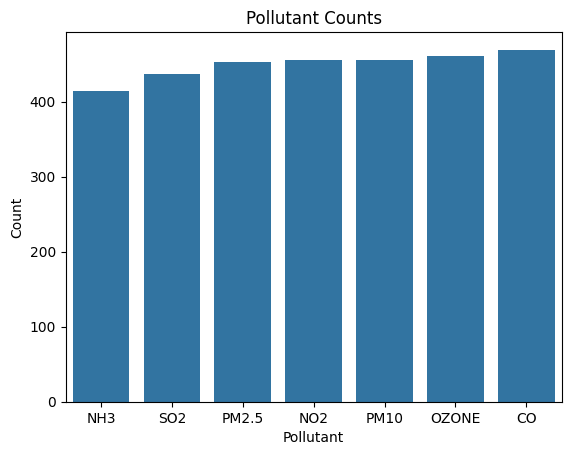

In [29]:
sns.barplot(x=pollutant_counts.index, y=pollutant_counts.values)
plt.xlabel('Pollutant')
plt.ylabel('Count')
plt.title('Pollutant Counts')
plt.show()

### PM2.5 Distribution

In [30]:
pm25 = df[df['pollutant_id'] == 'PM2.5'].copy()

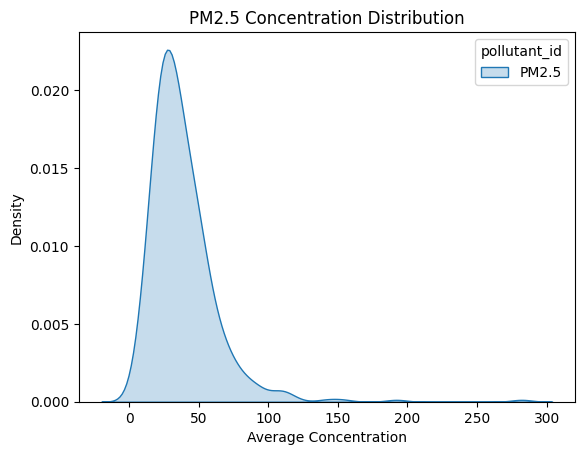

In [31]:
sns.kdeplot(data=pm25, x='avg_value', hue='pollutant_id', fill=True)
plt.xlabel('Average Concentration')
plt.ylabel('Density')
plt.title('PM2.5 Concentration Distribution')
plt.show()

### PM2.5 Category Distribution

For the 24-hour average PM2.5 concentration, the CPCB categories are:
| PM2.5 (µg/m³) | Category     |
| ------------: | ------------ |
|          0–30 | Good         |
|         31–60 | Satisfactory |
|         61–90 | Moderate     |
|        91–120 | Poor         |
|       121–250 | Very Poor    |
|          >250 | Severe       |


In [32]:
bins = [0, 30, 60, 90, 120, 250, float('inf')]

labels = [
    'Good',
    'Satisfactory',
    'Moderate',
    'Poor',
    'Very Poor',
    'Severe'
]

pm25['category'] = pd.cut(
    pm25['avg_value'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [33]:
pm25['category'].value_counts().sort_index()

,count
category,
Good,195
Satisfactory,202
Moderate,40
Poor,11
Very Poor,3
Severe,1


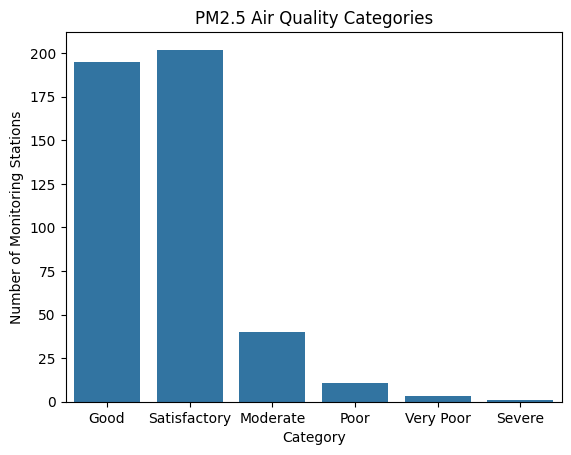

In [34]:
sns.barplot(x=pm25['category'].value_counts().sort_index().index, y=pm25['category'].value_counts().sort_index().values)

plt.title('PM2.5 Air Quality Categories')
plt.xlabel('Category')
plt.ylabel('Number of Monitoring Stations')
plt.xticks(rotation=0)

plt.show()

### Top states by average PM2.5

#### Which states have the highest average PM2.5 concentration?

PM2.5 is one of the most important air quality indicators.

In [35]:
state_pm25_avg = pm25.groupby('state')['avg_value'].mean().sort_values(ascending=False)
state_pm25_avg

,avg_value
state,
Meghalaya,108.000000
Bihar,66.391304
Delhi,54.146341
Haryana,54.037037
Punjab,50.428571
Himachal Pradesh,49.000000
Assam,46.833333
Andhra Pradesh,45.625000
Uttar Pradesh,43.766667


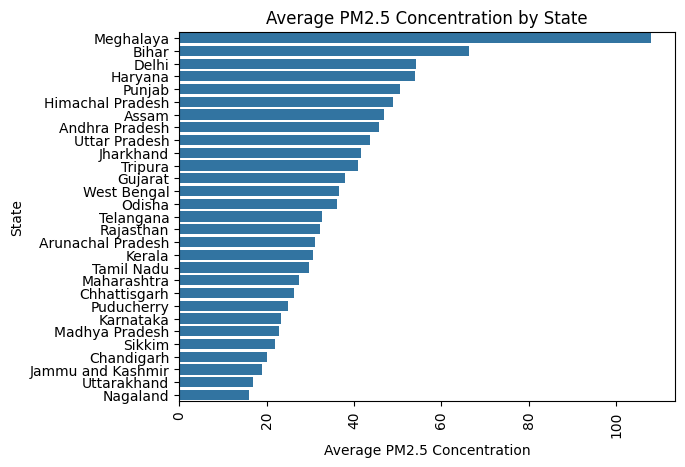

In [36]:
sns.barplot(x=state_pm25_avg.values, y=state_pm25_avg.index,orient='h')
plt.xlabel('Average PM2.5 Concentration')
plt.ylabel('State')
plt.title('Average PM2.5 Concentration by State')
plt.xticks(rotation=90)
plt.show()

#### How many monitoring stations contributed to each state's average PM2.5?

In [37]:
pm25_avg_by_state = pm25.groupby('state').agg(stations=('station', 'nunique'), avg_pm25=('avg_value', 'mean')).sort_values(by='avg_pm25', ascending=False)
pm25_avg_by_state

,stations,avg_pm25
state,,
Meghalaya,1,108.000000
Bihar,23,66.391304
Delhi,41,54.146341
Haryana,27,54.037037
Punjab,7,50.428571
Himachal Pradesh,1,49.000000
Assam,6,46.833333
Andhra Pradesh,16,45.625000
Uttar Pradesh,60,43.766667


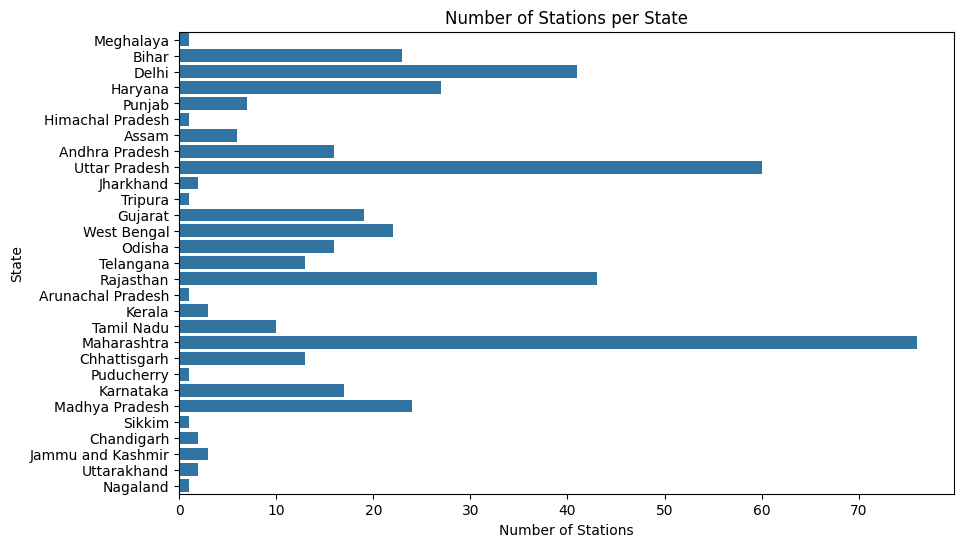

In [38]:
plt.figure(figsize=(10, 6))
sns.barplot(x=pm25_avg_by_state['stations'], y=pm25_avg_by_state.index, orient='h')
plt.xlabel('Number of Stations')
plt.ylabel('State')
plt.title('Number of Stations per State')
plt.show()


**Observation**

Meghalaya's ranking is based on one station, while Delhi's is based on many stations.

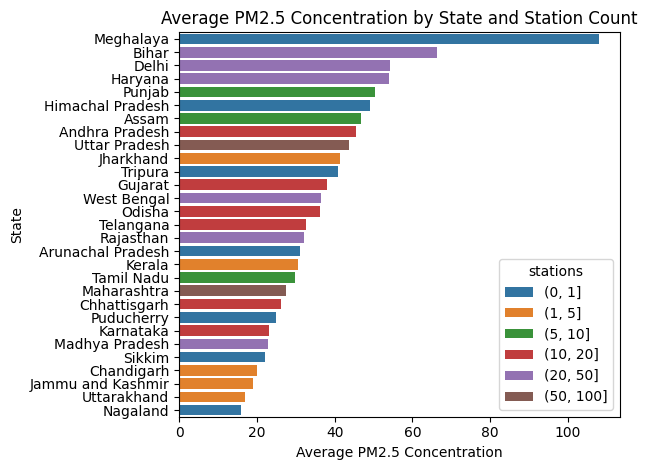

In [39]:
sns.barplot(data=pm25_avg_by_state, x='avg_pm25', y='state', hue=pd.cut(pm25_avg_by_state["stations"], bins=[0, 1, 5, 10, 20, 50, 100]), orient='h', errorbar=None)
plt.xlabel('Average PM2.5 Concentration')
plt.ylabel('State')
plt.title('Average PM2.5 Concentration by State and Station Count')
plt.tight_layout()
plt.show()

### PM2.5 Category Distribution by State

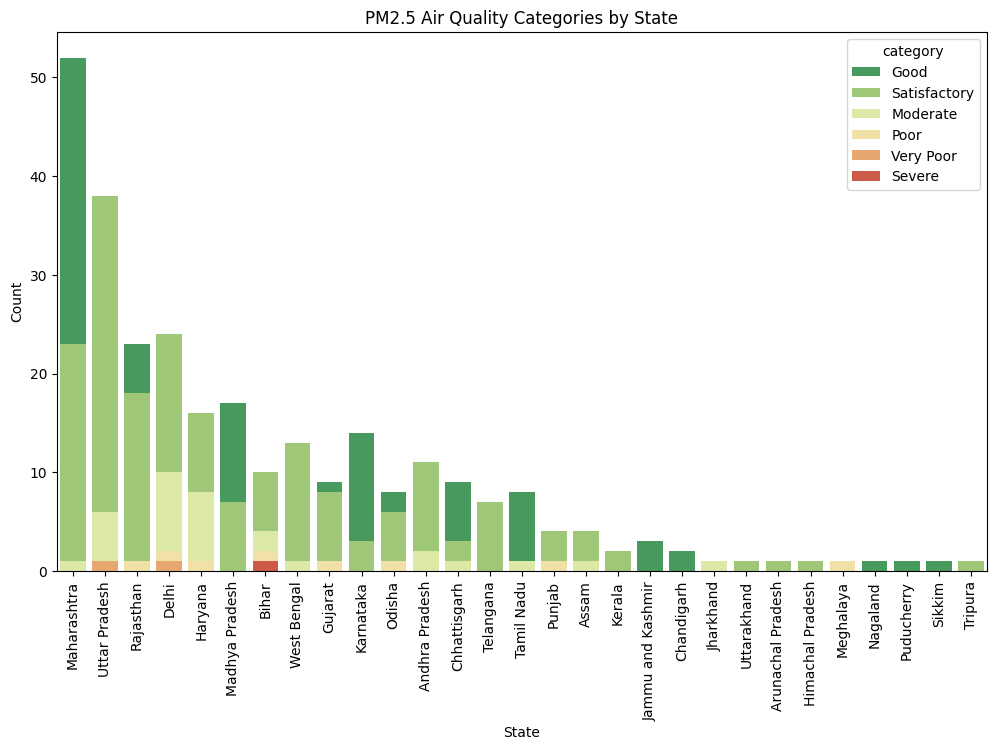

In [40]:
# Show number of occurences of each category of AQI by state
plt.figure(figsize=(12, 7))

sns.countplot(data=pm25, x='state', hue='category', order=pm25['state'].value_counts().index, dodge=False, palette='RdYlGn_r')
plt.xlabel('State')
plt.ylabel('Count')
plt.title('PM2.5 Air Quality Categories by State')
plt.xticks(rotation=90)
plt.show()

In [41]:
# Only show poor and very poor category distribution by state
pm25_poor_very_poor = pm25[pm25['category'].isin(['Poor', 'Very Poor', 'Severe'])]
pm25_poor_very_poor.head()

,state,city,station,last_update,latitude,longitude,pollutant_id,min_value,max_value,avg_value,category
4,Bihar,Bhagalpur,"Mayaganj, Bhagalpur - BSPCB",2026-08-02 19:00:00,25.265194,87.012947,PM2.5,13.0,483.0,110.0,Poor
153,Delhi,Delhi,"Sonia Vihar, Delhi - DPCC",2026-08-02 19:00:00,28.710508,77.249485,PM2.5,13.0,230.0,92.0,Poor
194,Gujarat,Nandesari,"GIDC, Nandesari - Nandesari Ind. Association",2026-08-02 19:00:00,22.410802,73.097923,PM2.5,7.0,339.0,118.0,Poor
532,Odisha,Bileipada,"Tata Township, Bileipada - OSPCB",2026-08-02 19:00:00,22.061567,85.474096,PM2.5,49.0,159.0,93.0,Poor
596,Uttar Pradesh,Khora,"Prashant Garden, Khora - UPPCB",2026-08-02 19:00:00,28.611190,77.342060,PM2.5,60.0,187.0,100.0,Poor


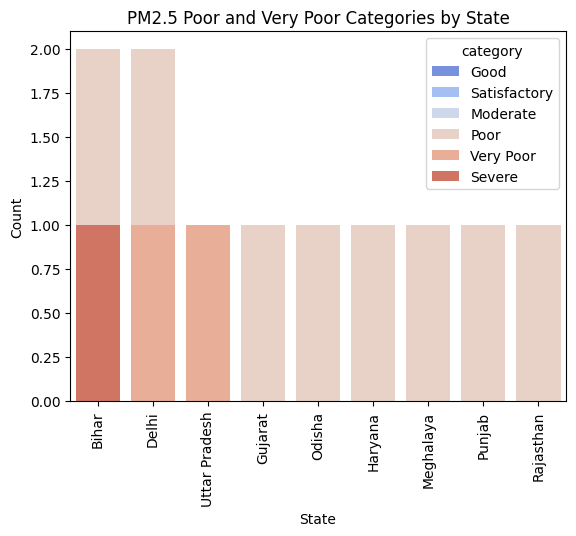

In [42]:
sns.countplot(data=pm25_poor_very_poor, x='state', hue='category', order=pm25_poor_very_poor['state'].value_counts().index, dodge=False, palette='coolwarm')  # dodge=False to stack bars
plt.xlabel('State')
plt.ylabel('Count')
plt.title('PM2.5 Poor and Very Poor Categories by State')
plt.xticks(rotation=90)
plt.show()

### Top cities by average PM2.5

#### Which cities have the highest average PM2.5?

In [43]:
pm25_top20_by_cities = pm25.groupby(['state', 'city'])['avg_value'].mean().sort_values(ascending=False).head(20)
pm25_top20_by_cities

state          city            
Bihar          Bihar Sharif        282.000000
               Buxar               142.000000
Gujarat        Nandesari           118.000000
Bihar          Chhapra             112.000000
               Bhagalpur           110.000000
Meghalaya      Byrnihat            108.000000
Uttar Pradesh  Khora               100.000000
Odisha         Bileipada            93.000000
Rajasthan      Udaipur              92.000000
Punjab         Mandi Gobindgarh     91.000000
Assam          Byrnihat             85.000000
Tamil Nadu     Gummidipoondi        80.000000
Bihar          Siwan                78.000000
               Samastipur           77.000000
Haryana        Dharuhera            76.000000
Uttar Pradesh  Lucknow              72.833333
Haryana        Gurugram             72.000000
Punjab         Amritsar             69.000000
Rajasthan      Alwar                69.000000
Haryana        Mandikhera           68.000000
Name: avg_value, dtype: float64

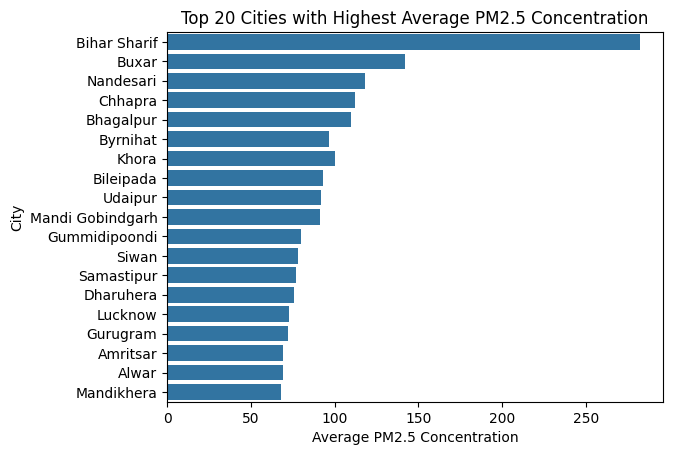

In [44]:
sns.barplot(data=pm25_top20_by_cities.reset_index(), x='avg_value', y='city', orient='h',errorbar=None)
plt.xlabel('Average PM2.5 Concentration')
plt.ylabel('City')
plt.title('Top 20 Cities with Highest Average PM2.5 Concentration')
plt.show()

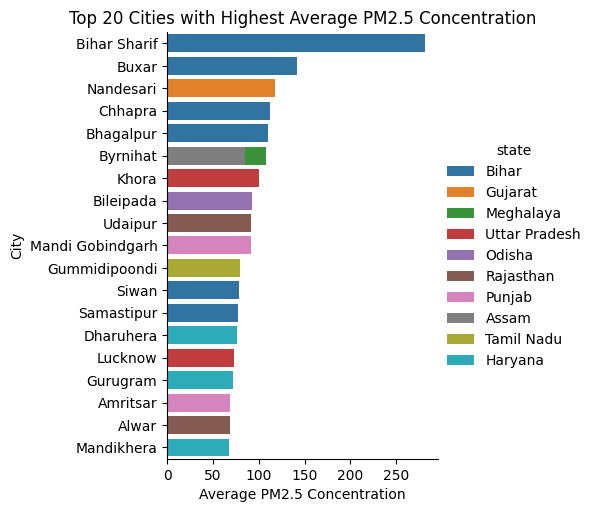

In [45]:
sns.catplot(data=pm25_top20_by_cities.reset_index(), x='avg_value', y='city', hue='state', orient='h', kind='bar', errorbar=None, dodge=False)
plt.xlabel('Average PM2.5 Concentration')
plt.ylabel('City')
plt.title('Top 20 Cities with Highest Average PM2.5 Concentration')
plt.show()

In [46]:
top_20_cities_by_category = pm25.groupby(['city', 'category'])['avg_value'].mean().sort_values(ascending=False).nlargest(20)
top_20_cities_by_category

/tmp/ipykernel_1958/1910534995.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_20_cities_by_category = pm25.groupby(['city', 'category'])['avg_value'].mean().sort_values(ascending=False).nlargest(20)


,,avg_value
city,category,
Bihar Sharif,Severe,282.0
Lucknow,Very Poor,192.0
Delhi,Very Poor,153.0
Buxar,Very Poor,142.0
Nandesari,Poor,118.0
Chhapra,Poor,112.0
Bhagalpur,Poor,110.0
Byrnihat,Poor,108.0
Gurugram,Poor,105.0


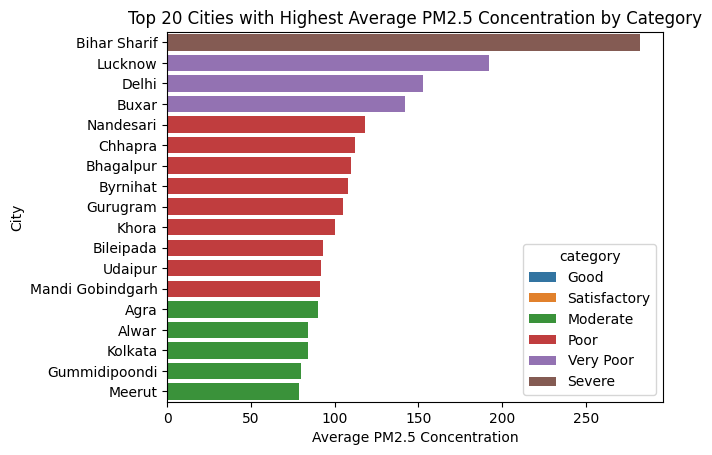

In [47]:
sns.barplot(data=top_20_cities_by_category.reset_index(), x='avg_value', y='city', hue='category', orient='h',errorbar=None, dodge=False)
plt.xlabel('Average PM2.5 Concentration')
plt.ylabel('City')
plt.title('Top 20 Cities with Highest Average PM2.5 Concentration by Category')
plt.show()

#### Cities with lowest PM2.5

In [48]:
#cities with cleanest air quality
pm25_bottom20_by_cities = pm25.groupby(['state', 'city'])['avg_value'].mean().sort_values(ascending=False).tail(20)
pm25_bottom20_by_cities

state           city      
Chhattisgarh    Kunjemura     15.000000
Rajasthan       Nagaur        14.000000
                Karauli       14.000000
Tamil Nadu      Coimbatore    14.000000
Madhya Pradesh  Bhopal        13.333333
Gujarat         Vapi          13.000000
Madhya Pradesh  Indore        13.000000
Odisha          Rairangpur    12.000000
Madhya Pradesh  Sagar         12.000000
Karnataka       Yadgir        12.000000
Chhattisgarh    Bhilai        11.666667
Rajasthan       Barmer        11.000000
                Bharatpur     11.000000
Odisha          Tensa         10.000000
Madhya Pradesh  Damoh         10.000000
Karnataka       Ramanagara     9.000000
                Belgaum        8.000000
Maharashtra     Dombivli       7.000000
Karnataka       Madikeri       6.000000
Uttarakhand     Rishikesh      2.000000
Name: avg_value, dtype: float64

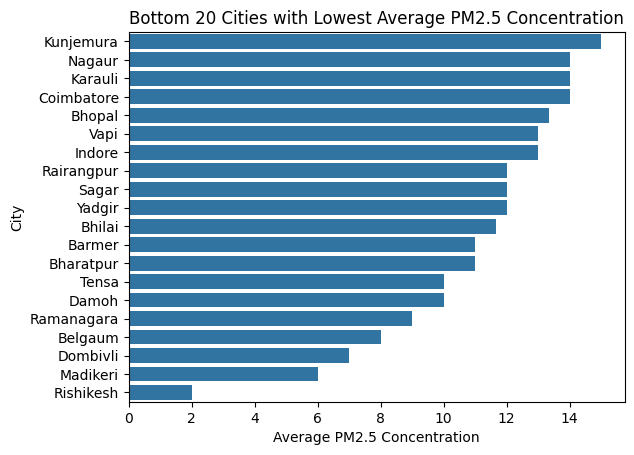

In [49]:
sns.barplot(data=pm25_bottom20_by_cities.reset_index(), x='avg_value', y='city', orient='h',errorbar=None)
plt.xlabel('Average PM2.5 Concentration')
plt.ylabel('City')
plt.title('Bottom 20 Cities with Lowest Average PM2.5 Concentration')
plt.show()

### Top monitoring stations for PM2.5

#### Which monitoring stations have the highest PM2.5?

In [50]:
# Create a separate column just for station names only without the suffix acronym for agency operating the monitoring station
pm25['station_short'] = pm25['station'].str.split(' - ').str[0]
pm25.head()

,state,city,station,last_update,latitude,longitude,pollutant_id,min_value,max_value,avg_value,category,station_short
4,Bihar,Bhagalpur,"Mayaganj, Bhagalpur - BSPCB",2026-08-02 19:00:00,25.265194,87.012947,PM2.5,13.0,483.0,110.0,Poor,"Mayaganj, Bhagalpur"
25,Andhra Pradesh,Visakhapatnam,"GVM Corporation, Visakhapatnam - APPCB",2026-08-02 19:00:00,17.720000,83.300000,PM2.5,3.0,130.0,41.0,Satisfactory,"GVM Corporation, Visakhapatnam"
30,Arunachal Pradesh,Naharlagun,"Naharlagun, Naharlagun - APSPCB",2026-08-02 19:00:00,27.103358,93.679645,PM2.5,8.0,69.0,31.0,Satisfactory,"Naharlagun, Naharlagun"
34,Assam,Guwahati,"Railway Colony, Guwahati - PCBA",2026-08-02 19:00:00,26.181742,91.780630,PM2.5,2.0,91.0,58.0,Satisfactory,"Railway Colony, Guwahati"
36,Assam,Guwahati,"Pan Bazaar, Guwahati - PCBA",2026-08-02 19:00:00,26.187500,91.744194,PM2.5,0.0,50.0,17.0,Good,"Pan Bazaar, Guwahati"


In [51]:
pm25_avg_by_station = pm25.groupby('station_short')['avg_value'].mean().sort_values(ascending=False).head(20)
pm25_avg_by_station

,avg_value
station_short,
"D M Colony, Bihar Sharif",282.0
"Gomti Nagar, Lucknow",192.0
"Anand Vihar, Delhi",153.0
"Charitra Van, Buxar",142.0
"GIDC, Nandesari",118.0
"Darshan Nagar, Chhapra",112.0
"Wazirpur, Delhi",111.0
"Mayaganj, Bhagalpur",110.0
"15th Mile-Nongthymmai, Byrnihat -Meghalaya PCB",108.0


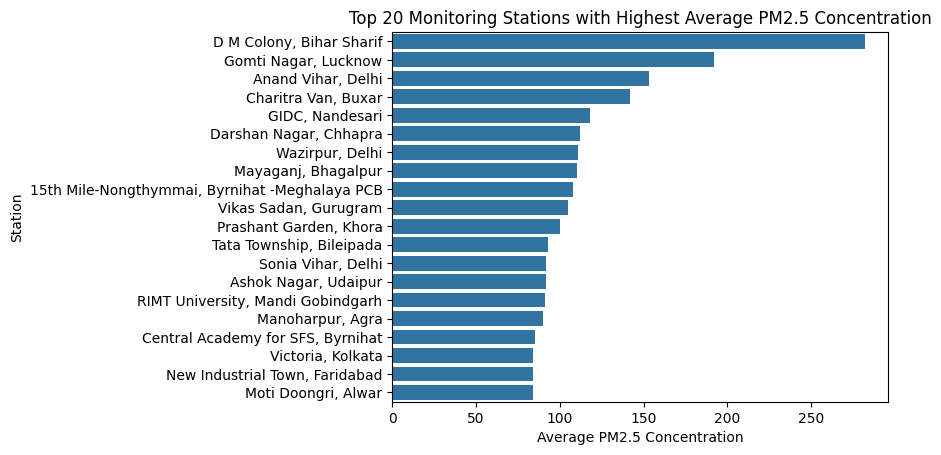

In [52]:
sns.barplot(data=pm25_avg_by_station.reset_index(), x='avg_value', y='station_short', orient='h',errorbar=None)
plt.xlabel('Average PM2.5 Concentration')
plt.ylabel('Station')
plt.title('Top 20 Monitoring Stations with Highest Average PM2.5 Concentration')
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 76.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 71.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 79.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 15.0% of the points cannot be plac

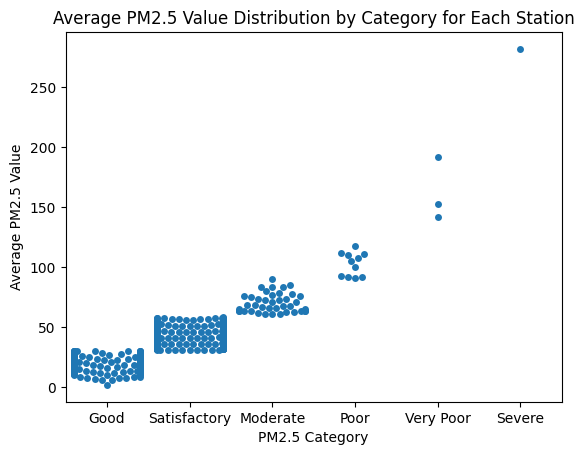

In [53]:
sns.swarmplot(data=pm25, x='category', y='avg_value')
plt.xlabel('PM2.5 Category')
plt.ylabel('Average PM2.5 Value')
plt.title('Average PM2.5 Value Distribution by Category for Each Station')
plt.show()

### Monitoring coverage

#### Which states have the most monitoring stations?

In [54]:
total_station_by_state = df.groupby('state')['station'].nunique().sort_values(ascending=False)
total_station_by_state

,station
state,
Maharashtra,82
Uttar Pradesh,62
Rajasthan,47
Delhi,44
Haryana,29
Bihar,28
Madhya Pradesh,26
West Bengal,22
Karnataka,20


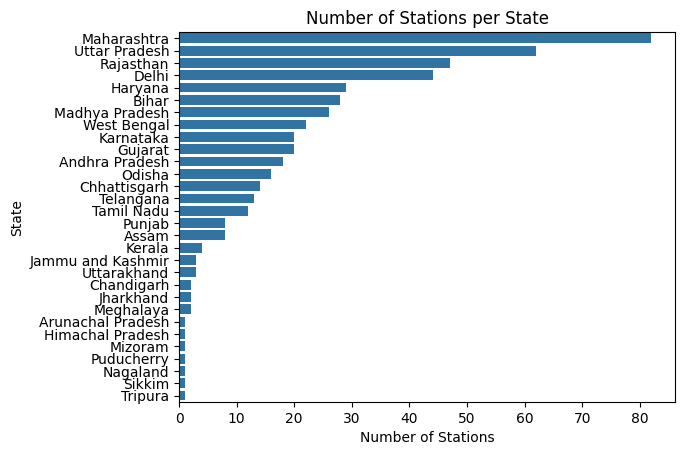

In [55]:
sns.barplot(x=total_station_by_state.values, y=total_station_by_state.index,orient='h')
plt.xlabel('Number of Stations')
plt.ylabel('State')
plt.title('Number of Stations per State')
plt.show()

#### Which cities have the most monitoring stations?

In [56]:
total_station_by_city = df.groupby('city')['station'].nunique().sort_values(ascending=False).head(20)
total_station_by_city

,station
city,
Delhi,44
Mumbai,22
Hyderabad,13
Kolkata,7
Chennai,7
Ghaziabad,7
Ahmedabad,7
Jaipur,6
Lucknow,6


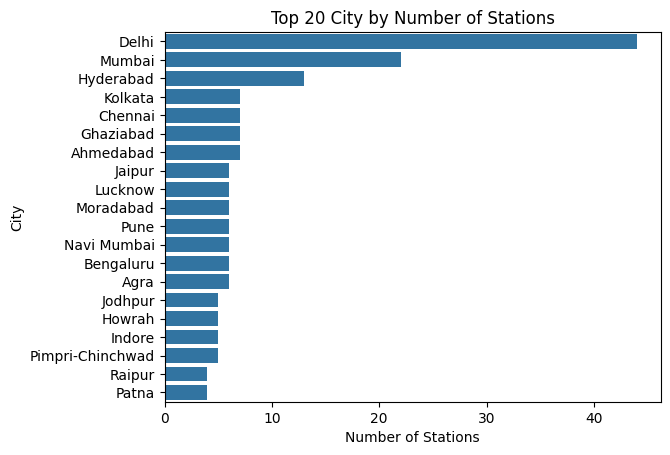

In [57]:
sns.barplot(x=total_station_by_city.values, y=total_station_by_city.index,orient='h')
plt.xlabel('Number of Stations')
plt.ylabel('City')
plt.title('Top 20 City by Number of Stations')
plt.show()

### Compare pollutant types

#### Which pollutant has the highest average concentration?

In [58]:
pollutant_by_avg = df.groupby('pollutant_id')['avg_value'].mean().sort_values(ascending=False)
pollutant_by_avg

,avg_value
pollutant_id,
PM10,52.747253
PM2.5,38.431416
CO,29.876333
OZONE,25.873913
NO2,18.523077
SO2,12.418764
NH3,4.874396


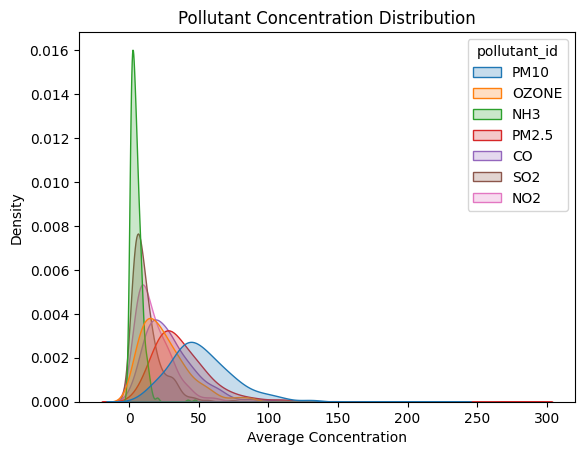

In [59]:
sns.kdeplot(data=df, x='avg_value', hue='pollutant_id', fill=True)
plt.xlabel('Average Concentration')
plt.ylabel('Density')
plt.title('Pollutant Concentration Distribution')
plt.show()

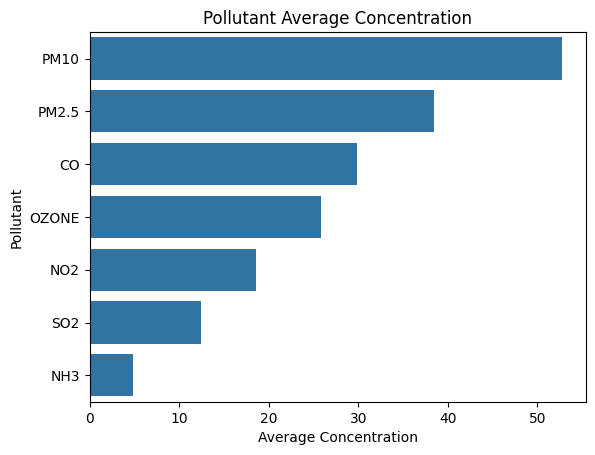

In [60]:
sns.barplot(x=pollutant_by_avg.values, y=pollutant_by_avg.index,orient='h')
plt.xlabel('Average Concentration')
plt.ylabel('Pollutant')
plt.title('Pollutant Average Concentration')
plt.show()

#### How do pollutant concentrations vary?

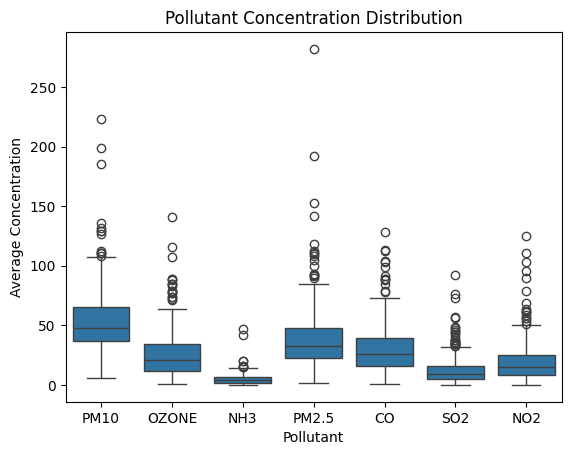

In [61]:
sns.boxplot(data=df, x='pollutant_id', y='avg_value')
plt.xlabel('Pollutant')
plt.ylabel('Average Concentration')
plt.title('Pollutant Concentration Distribution')
plt.show()

In [62]:
df.groupby('pollutant_id')['avg_value'].median().sort_values(ascending=False)

,avg_value
pollutant_id,
PM10,48.0
PM2.5,33.0
CO,26.0
OZONE,21.0
NO2,15.0
SO2,9.0
NH3,4.0


**Highest Median**

PM10 exhibits the highest median concentration among all monitored pollutants, indicating that coarse particulate matter is consistently present at higher levels across monitoring stations. PM2.5 also shows relatively high median concentrations, while NH3 and SO2 generally remain at lower levels.

In [63]:
q1 = df.groupby('pollutant_id')['avg_value'].quantile(0.25)
q3 = df.groupby('pollutant_id')['avg_value'].quantile(0.75)

iqr = (q3 - q1).sort_values(ascending=False)

iqr

,avg_value
pollutant_id,
PM10,28.5
PM2.5,25.0
CO,23.0
OZONE,22.0
NO2,17.0
SO2,11.0
NH3,5.0


**Greatest variability**

PM10 demonstrates the greatest variability, suggesting that concentrations differ considerably across monitoring locations. In contrast, NH3 concentrations are relatively consistent, with a much narrower distribution.

In [64]:
outlier_summary = {}

for pollutant in df['pollutant_id'].unique():
    values = df[df['pollutant_id'] == pollutant]['avg_value']

    Q1 = values.quantile(0.25)
    Q3 = values.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = values[(values < lower) | (values > upper)]

    outlier_summary[pollutant] = {
        'Outlier Count': len(outliers),
        'Max Outlier': outliers.max()
    }

pd.DataFrame(outlier_summary).T.sort_values('Max Outlier', ascending=False)

,Outlier Count,Max Outlier
PM2.5,16.0,282.0
PM10,13.0,223.0
OZONE,18.0,141.0
CO,13.0,128.0
NO2,16.0,125.0
SO2,24.0,92.0
NH3,8.0,47.0


### Correlation between pollutants

#### Do different pollutants track together at the same monitoring station?

In [65]:
pollutant_by_station_pivot = df.pivot_table(index='station', columns='pollutant_id', values='avg_value', aggfunc='mean')



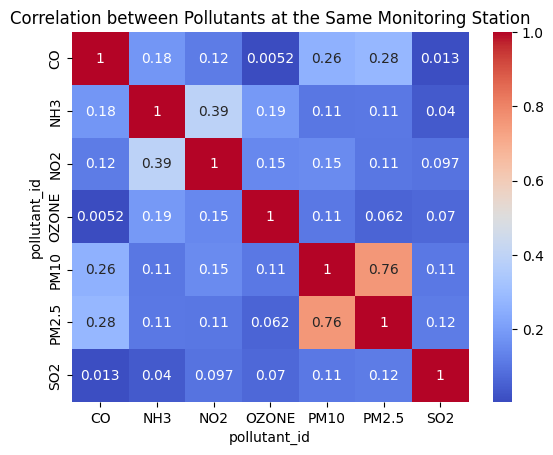

In [66]:
sns.heatmap(pollutant_by_station_pivot.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between Pollutants at the Same Monitoring Station')
plt.show()

**Observations**

PM2.5 and PM10 show a strong positive correlation (0.77), confirming they consistently scale together as part of overall dust and particulate pollution.

Gaseous pollutants like SO2, CO, and OZONE show very low correlation with each other (mostly under 0.25). This tells us that pollution spikes at a single station are usually driven by specific, independent local sources (e.g., a localized traffic surge vs. a distant industrial plume) rather than a single unified source.

Sulfur Dioxide behaves entirely independently of all other measured pollutants, suggesting industrial emissions do not track with urban commercial or vehicular patterns.

### Punjab State - Pollutant Analysis

In [67]:
df_punjab = df[df['state'] == 'Punjab']

avg_by_city_punjab = df_punjab.groupby(['city', 'pollutant_id'])['avg_value'].mean().sort_values(ascending=False)
avg_by_city_punjab

city              pollutant_id
Mandi Gobindgarh  PM10            111.0
                  PM2.5            91.0
Bathinda          CO               78.0
Amritsar          PM10             74.0
                  PM2.5            69.0
Khanna            PM10             65.0
Ludhiana          PM10             65.0
Jalandhar         PM10             63.0
Bathinda          PM10             57.0
Rupnagar          CO               55.0
Ludhiana          PM2.5            54.0
Khanna            CO               46.0
                  PM2.5            45.0
Ludhiana          NO2              42.0
Jalandhar         NO2              41.0
                  OZONE            40.0
Mandi Gobindgarh  CO               40.0
Patiala           OZONE            40.0
                  PM10             40.0
Khanna            OZONE            39.0
Bathinda          PM2.5            38.0
Jalandhar         PM2.5            37.0
                  CO               35.0
Amritsar          CO               34.0
Mandi Gobindgarh  OZONE            29.0
Bathinda          NO2              28.0
Khanna            NO2              28.0
Ludhiana          CO               27.0
Rupnagar          NO2              26.0
Mandi Gobindgarh  NO2              24.0
Patiala           CO               24.0
Ludhiana          OZONE            23.0
Patiala           PM2.5            19.0
                  NO2              18.0
Amritsar          OZONE            18.0
Mandi Gobindgarh  SO2              17.0
Amritsar          SO2              16.0
Bathinda          SO2              15.0
Khanna            SO2              15.0
Jalandhar         SO2              15.0
Rupnagar          SO2              13.0
Ludhiana          SO2              12.0
Patiala           SO2              11.0
Ludhiana          NH3               8.0
Khanna            NH3               7.0
Patiala           NH3               6.0
Mandi Gobindgarh  NH3               5.0
Jalandhar         NH3               4.0
Name: avg_value, dtype: float64

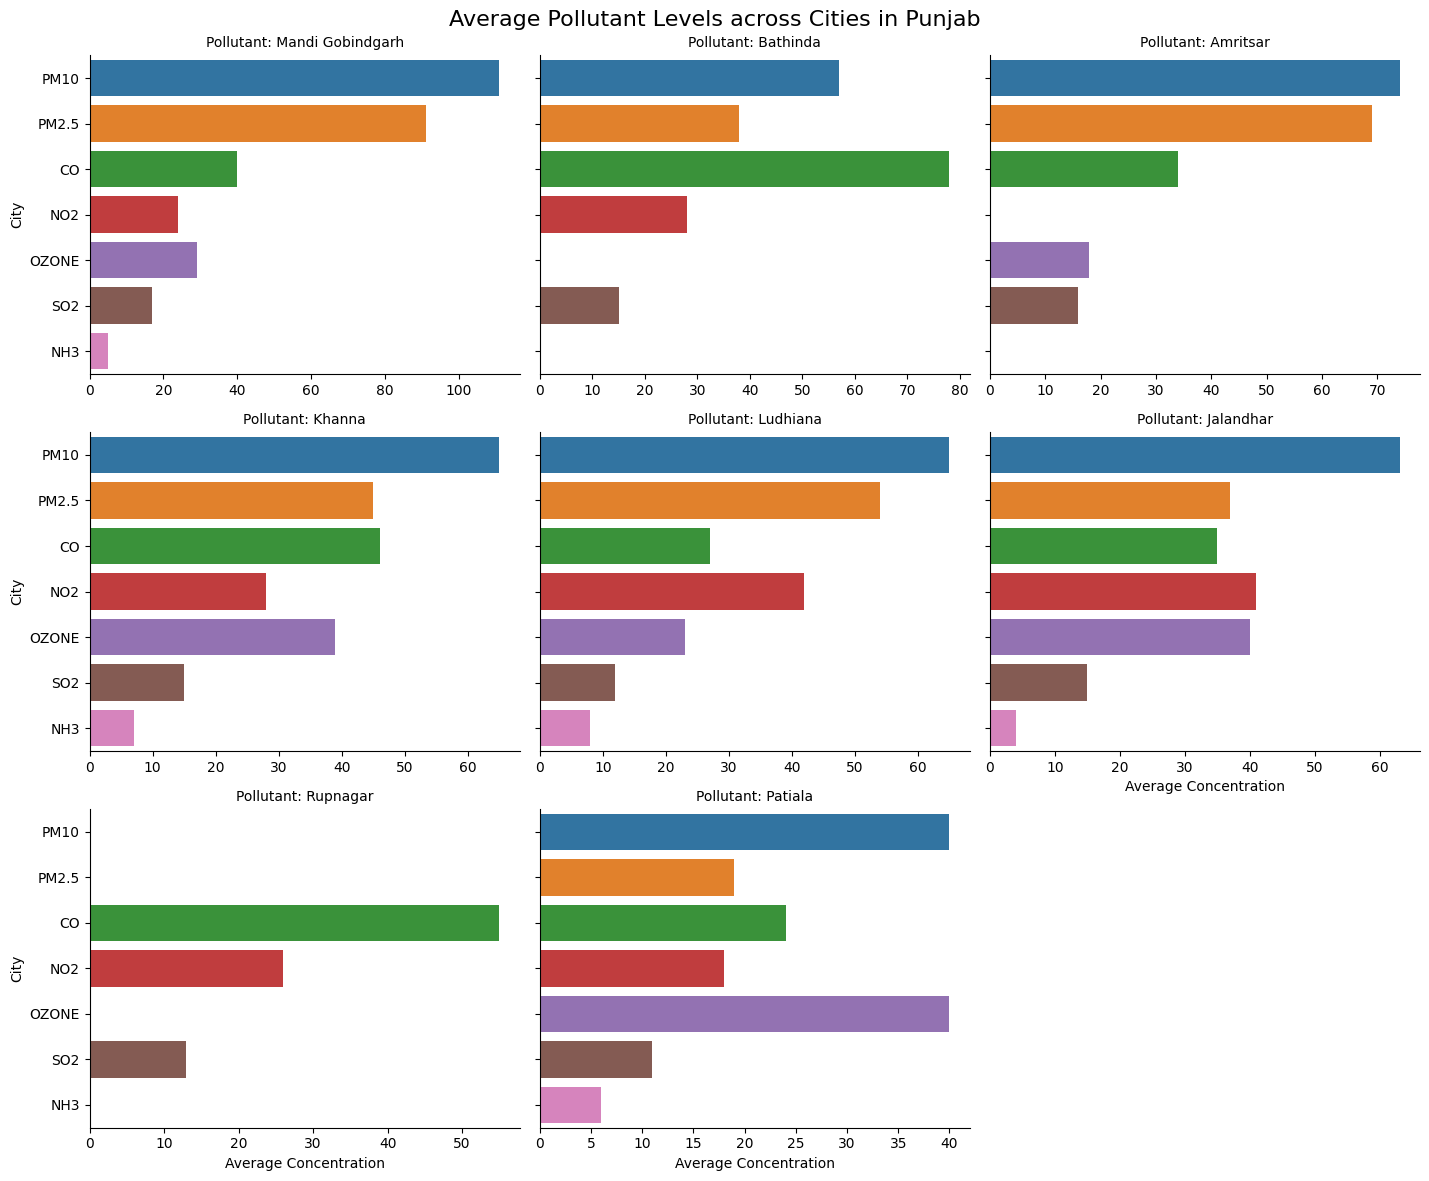

In [68]:
# Create the grid of bar plots
g = sns.catplot(
    data=avg_by_city_punjab.reset_index(),
    x="avg_value",
    y="pollutant_id",
    col="city",
    col_wrap=3,
    kind="bar",
    orient="h",
    height=4,
    aspect=1.2,
    sharex=False,
    errorbar=None,
    hue="pollutant_id"
)

# Customizing labels and title
g.set_axis_labels("Average Concentration", "City")
g.set_titles(col_template="Pollutant: {col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Average Pollutant Levels across Cities in Punjab", fontsize=16)

plt.tight_layout()
plt.show()

In [69]:
df_punjab[df['city']=='Patiala'].groupby('pollutant_id')['avg_value'].mean().sort_values(ascending=False)

/tmp/ipykernel_1958/619004993.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_punjab[df['city']=='Patiala'].groupby('pollutant_id')['avg_value'].mean().sort_values(ascending=False)


,avg_value
pollutant_id,
OZONE,40.0
PM10,40.0
CO,24.0
PM2.5,19.0
NO2,18.0
SO2,11.0
NH3,6.0
